# 1. Importamos librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# 2. Cargamos los datos

In [ ]:
df = pd.read_csv("ad_viz_plotval_data.csv")

df.head()

,Date,Source,Site ID,POC,Daily Max 1-hour NO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2023,AQS,60370016,1,4.0,ppb,4,Glendora,24,100.0,...,Nitrogen dioxide (NO2),99,31080,"Los Angeles-Long Beach-Anaheim, CA",6,California,37,Los Angeles,34.14435,-117.85036
1,01/02/2023,AQS,60370016,1,9.2,ppb,8,Glendora,24,100.0,...,Nitrogen dioxide (NO2),99,31080,"Los Angeles-Long Beach-Anaheim, CA",6,California,37,Los Angeles,34.14435,-117.85036
2,01/03/2023,AQS,60370016,1,7.7,ppb,7,Glendora,21,88.0,...,Nitrogen dioxide (NO2),99,31080,"Los Angeles-Long Beach-Anaheim, CA",6,California,37,Los Angeles,34.14435,-117.85036
3,01/04/2023,AQS,60370016,1,14.8,ppb,13,Glendora,24,100.0,...,Nitrogen dioxide (NO2),99,31080,"Los Angeles-Long Beach-Anaheim, CA",6,California,37,Los Angeles,34.14435,-117.85036
4,01/05/2023,AQS,60370016,1,7.6,ppb,7,Glendora,24,100.0,...,Nitrogen dioxide (NO2),99,31080,"Los Angeles-Long Beach-Anaheim, CA",6,California,37,Los Angeles,34.14435,-117.85036


# 3. Información de los datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                364 non-null    object 
 1   Source                              364 non-null    object 
 2   Site ID                             364 non-null    int64  
 3   POC                                 364 non-null    int64  
 4   Daily Max 1-hour NO2 Concentration  364 non-null    float64
 5   Units                               364 non-null    object 
 6   Daily AQI Value                     364 non-null    int64  
 7   Local Site Name                     364 non-null    object 
 8   Daily Obs Count                     364 non-null    int64  
 9   Percent Complete                    364 non-null    float64
 10  AQS Parameter Code                  364 non-null    int64  
 11  AQS Parameter Description           364 non-n

# 4. Estadísticas descriptivas

In [ ]:
df.describe().round(2)

,Site ID,POC,Daily Max 1-hour NO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,364.0,364.0,364.00,364.00,364.00,364.00,364.0,364.0,364.0,364.0,364.0,364.00,364.00
mean,60370016.0,1.0,15.44,14.03,23.82,99.27,42602.0,99.0,31080.0,6.0,37.0,34.14,-117.85
std,0.0,0.0,8.19,7.89,0.72,2.98,0.0,0.0,0.0,0.0,0.0,0.00,0.00
min,60370016.0,1.0,2.70,2.00,19.00,79.00,42602.0,99.0,31080.0,6.0,37.0,34.14,-117.85
25%,60370016.0,1.0,10.50,9.00,24.00,100.00,42602.0,99.0,31080.0,6.0,37.0,34.14,-117.85
50%,60370016.0,1.0,13.70,12.00,24.00,100.00,42602.0,99.0,31080.0,6.0,37.0,34.14,-117.85
75%,60370016.0,1.0,18.23,17.00,24.00,100.00,42602.0,99.0,31080.0,6.0,37.0,34.14,-117.85
max,60370016.0,1.0,88.20,87.00,24.00,100.00,42602.0,99.0,31080.0,6.0,37.0,34.14,-117.85


# 5. Lista de características y variables

In [ ]:
l_column = list(df.columns)

len_feature = len(l_column)

l_column

['Date',
 'Source',
 'Site ID',
 'POC',
 'Daily Max 1-hour NO2 Concentration',
 'Units',
 'Daily AQI Value',
 'Local Site Name',
 'Daily Obs Count',
 'Percent Complete',
 'AQS Parameter Code',
 'AQS Parameter Description',
 'Method Code',
 'CBSA Code',
 'CBSA Name',
 'State FIPS Code',
 'State',
 'County FIPS Code',
 'County',
 'Site Latitude',
 'Site Longitude']

In [ ]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 1-hour NO2 Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

# 6. Revisar los años disponibles

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

print("Años disponibles:")
print(sorted(df['Date'].dt.year.unique()))

print("\nFecha inicial:", df['Date'].min())
print("Fecha final:", df['Date'].max())

Años disponibles:
[np.int32(2023)]

Fecha inicial: 2023-01-01 00:00:00
Fecha final: 2023-12-31 00:00:00


#7. Variable que vamos a estudiar

Para nuestra regresión utilizaremos:

Variable independiente (X): Daily AQI Value
Variable dependiente (Y): Daily Max 1-hour NO2 Concentration

El AQI representa el índice de calidad del aire, mientras que la concentración de NO₂ está expresada en ppb.

In [ ]:
x = df[['Daily AQI Value']]
y = df['Daily Max 1-hour NO2 Concentration']

x.head()

,Daily AQI Value
0,4
1,8
2,7
3,13
4,7


# 8. Pairplot

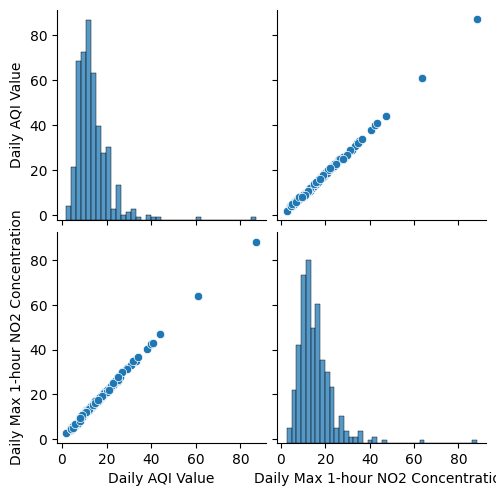

In [ ]:
sns.pairplot(
    df[['Daily AQI Value',
        'Daily Max 1-hour NO2 Concentration']]
)

plt.show()

# 9. Distribución de la concentración de NO₂

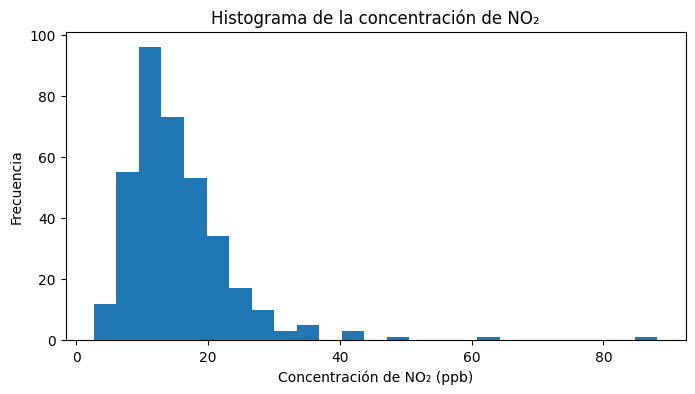

In [ ]:
df['Daily Max 1-hour NO2 Concentration'].plot.hist(
    bins=25,
    figsize=(8,4)
)

plt.title('Histograma de la concentración de NO₂')
plt.xlabel('Concentración de NO₂ (ppb)')
plt.ylabel('Frecuencia')

plt.show()

# 10. Densidad

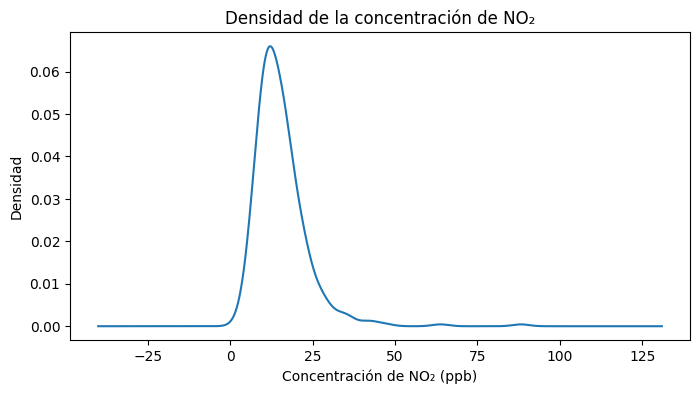

In [ ]:
df['Daily Max 1-hour NO2 Concentration'].plot.density(
    figsize=(8,4)
)

plt.title('Densidad de la concentración de NO₂')
plt.xlabel('Concentración de NO₂ (ppb)')
plt.ylabel('Densidad')

plt.show()

# 11. Gráfico de dispersión

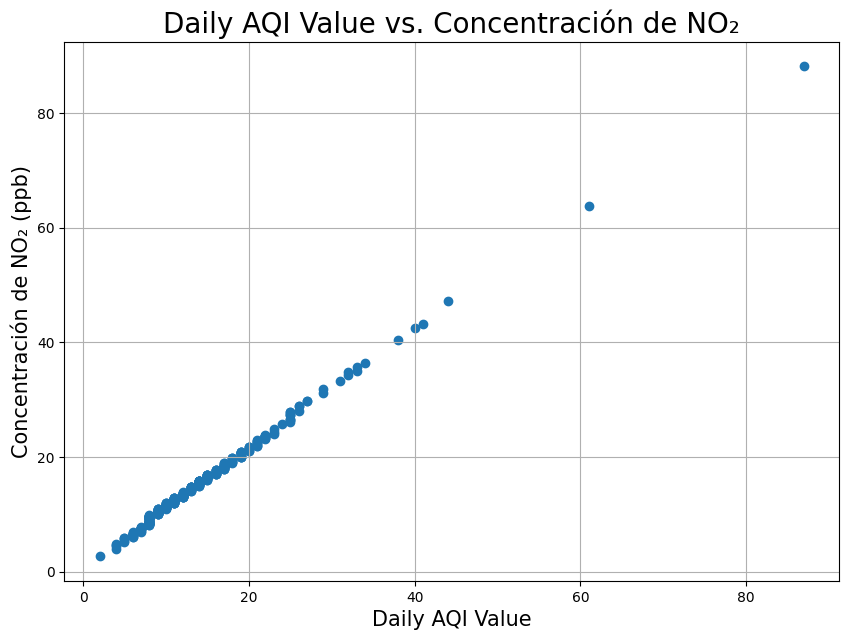

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    df['Daily AQI Value'],
    df['Daily Max 1-hour NO2 Concentration']
)

plt.title(
    'Daily AQI Value vs. Concentración de NO₂',
    fontsize=20
)

plt.xlabel(
    'Daily AQI Value',
    fontsize=15
)

plt.ylabel(
    'Concentración de NO₂ (ppb)',
    fontsize=15
)

plt.grid(True)

plt.show()

# 12. Matriz de correlación

In [ ]:
correlation = df[
    ['Daily AQI Value',
     'Daily Max 1-hour NO2 Concentration']
].corr()

correlation

,Daily AQI Value,Daily Max 1-hour NO2 Concentration
Daily AQI Value,1.000000,0.998471
Daily Max 1-hour NO2 Concentration,0.998471,1.000000


# 13. Mapa de calor

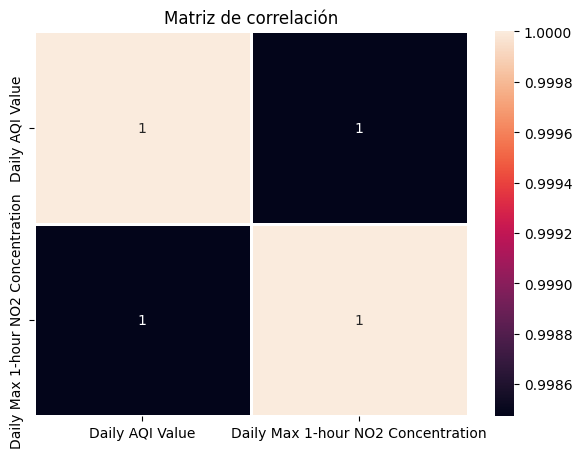

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    linewidths=1
)

plt.title('Matriz de correlación')

plt.show()

# 14. División de entrenamiento y prueba

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=123
)

print("Datos de entrenamiento:", x_train.shape)
print("Datos de prueba:", x_test.shape)

Datos de entrenamiento: (254, 1)
Datos de prueba: (110, 1)


# 15. Creación del modelo de regresión lineal

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

lm = LinearRegression()

# 16. Entrenamiento

In [ ]:
lm.fit(x_train, y_train)

LinearRegression()

# 17. Intercepto

In [ ]:
print("Intersección del modelo:", lm.intercept_)

Intersección del modelo: 0.7053369809708769


# 18. Coeficiente

In [ ]:
print("Coeficiente del modelo:", lm.coef_)

Coeficiente del modelo: [1.05084421]


# 19. Tabla de coeficientes

In [ ]:
cdf = pd.DataFrame(
    lm.coef_,
    index=x_train.columns,
    columns=['Coeficientes']
)

cdf

,Coeficientes
Daily AQI Value,1.050844


# 21. Predicciones

In [ ]:
predictions = lm.predict(x_test)

print("Primeras predicciones:")

predictions[:10]

Primeras predicciones:


array([13.31546748, 92.1287831 , 21.72222115, 12.26462327,  8.06124644,
       28.0272864 , 31.17981902, 15.4171559 , 20.67137694,  7.01040223])

# 22. Valores reales vs. predichos

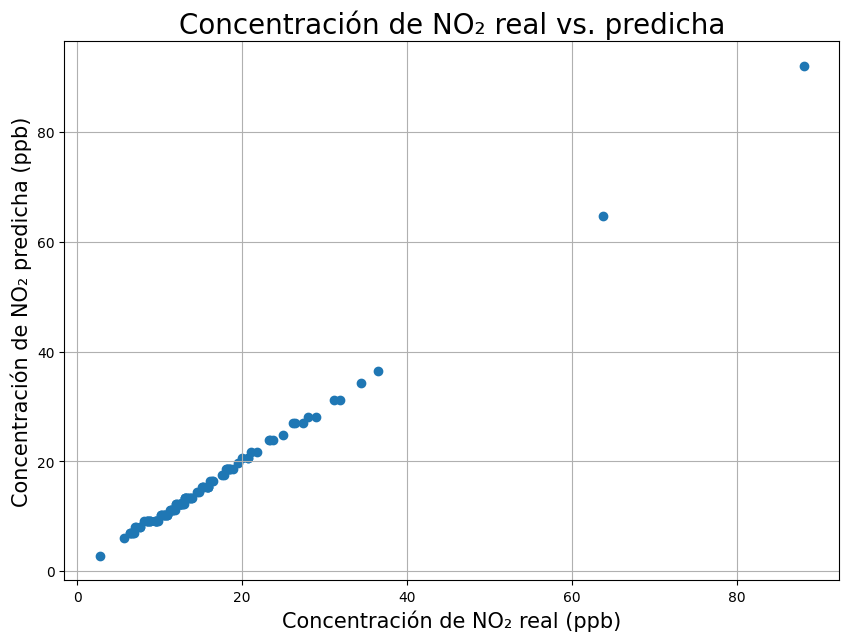

In [ ]:
plt.figure(figsize=(10,7))

plt.title(
    'Concentración de NO₂ real vs. predicha',
    fontsize=20
)

plt.xlabel(
    'Concentración de NO₂ real (ppb)',
    fontsize=15
)

plt.ylabel(
    'Concentración de NO₂ predicha (ppb)',
    fontsize=15
)

plt.scatter(
    y_test,
    predictions
)

plt.grid(True)

plt.show()

# 23. Residuos


In [ ]:
residuos = y_test - predictions

residuos.head()

,Daily Max 1-hour NO2 Concentration
167,-0.315467
170,-3.928783
11,-0.622221
309,-0.264623
41,-1.061246


# 24. Histograma de residuos



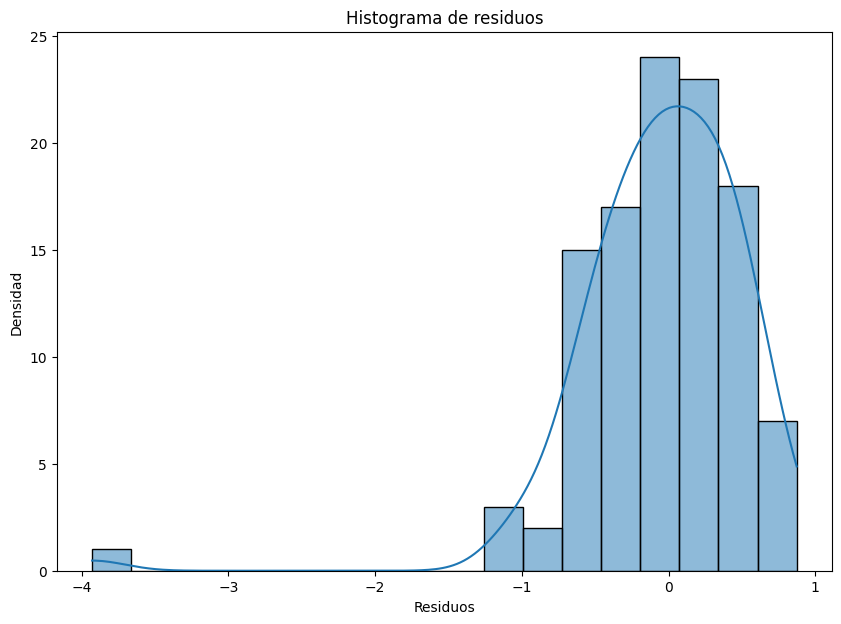

In [ ]:
plt.figure(figsize=(10,7))

sns.histplot(
    residuos,
    kde=True
)

plt.title(
    'Histograma de residuos'
)

plt.xlabel('Residuos')
plt.ylabel('Densidad')

plt.show()

# 25. Homocedasticidad

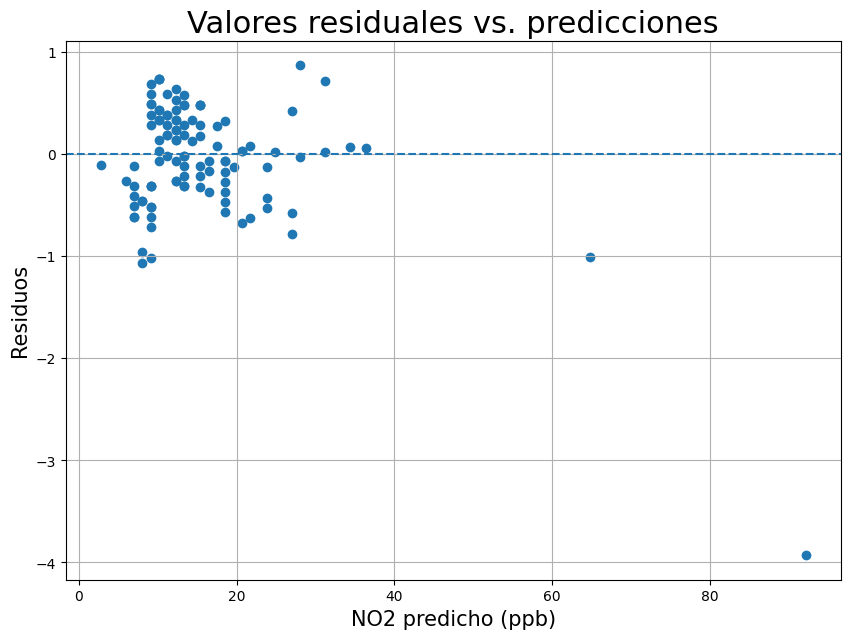

In [ ]:
plt.figure(figsize=(10, 7))

plt.title(
    "Valores residuales vs. predicciones",
    fontsize=22
)

plt.xlabel(
    "NO2 predicho (ppb)",
    fontsize=15
)

plt.ylabel(
    "Residuos",
    fontsize=15
)

plt.scatter(
    predictions,
    residuos
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.grid(True)
plt.show()

# 26. Comparación de valores

In [ ]:
resultados = pd.DataFrame({
    'Valor real': y_test.values,
    'Valor predicho': predictions,
    'Residuo': residuos.values
})

resultados.head(10)

,Valor real,Valor predicho,Residuo
0,13.0,13.315467,-0.315467
1,88.2,92.128783,-3.928783
2,21.1,21.722221,-0.622221
3,12.0,12.264623,-0.264623
4,7.0,8.061246,-1.061246
5,28.9,28.027286,0.872714
6,31.2,31.179819,0.020181
7,15.9,15.417156,0.482844
8,20.0,20.671377,-0.671377
9,6.4,7.010402,-0.610402


# 27. Error cuadrático medio — MSE

In [ ]:
mse = metrics.mean_squared_error(
    y_test,
    predictions
)

print("Mean Square Error (MSE):", mse)

Mean Square Error (MSE): 0.32882586500558364


# 28. R²

In [ ]:
r2 = lm.score(x_test, y_test)

print("Coeficiente de determinación R²:", r2)

Coeficiente de determinación R²: 0.9970541312509252


# 29. Mínimos cuadrados

In [ ]:
import statsmodels.api as sm

In [ ]:
Xs = sm.add_constant(x)

stat_model = sm.OLS(y, Xs)

stat_result = stat_model.fit()

print(stat_result.summary())

                                    OLS Regression Results                                    
Dep. Variable:     Daily Max 1-hour NO2 Concentration   R-squared:                       0.997
Model:                                            OLS   Adj. R-squared:                  0.997
Method:                                 Least Squares   F-statistic:                 1.181e+05
Date:                                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                                        20:45:02   Log-Likelihood:                -227.62
No. Observations:                                 364   AIC:                             459.2
Df Residuals:                                     362   BIC:                             467.0
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                      coef    std err          t  